# Retail Customer Analysis Summative Lab
## Understanding Customer Behavior Across Store Locations

### Introduction

This summative lab bridges the concepts and techniques learned throughout the course with their practical application to a real-world industry scenario. You will step into the role of a junior data analyst for a retail company and apply your skills to evaluate customer behavior, satisfaction, and promotional impacts. By following the outlined process, you will gain experience in experimental design, statistical testing, and actionable decision-making.

Your task is not only to conduct the analysis but also to reflect on how these techniques help solve real-world problems that businesses face daily.

By completing this lab, you will have:
- Practiced designing and executing statistical analyses in a real-world scenario.
- Reinforced your understanding of test selection and assumptions.
- Applied statistical results to business decision-making.
- Developed skills in communicating insights effectively through visualizations and reports.

### Business Scenario Questions:
Imagine you are a junior data analyst working for a retail company that operates stores in three distinct regions: City Center, Suburb, and Rural. Your manager has tasked you with analyzing customer behavior and preferences across these locations. The goal is to help the company answer two key questions:
1. Do customer spending patterns, satisfaction levels, and product preferences differ across store locations?
2. Do promotional periods result in significantly higher spending compared to non-promotional periods?

Spending Across Location:

- Business-relevant MDE: Absolute difference in spending of 15% or more
- Justification: This represents enough of a difference to warrant location-specific strategies (inventory, staffing, etc.)


Ratings Across Locations:

- Business-relevant MDE: 1.0 point difference between locations
- Justification: On a 10-point scale, a one point difference is noticeable and actionable for customer service improvements

Promotional Spending:

- Business-relevant MDE: A $15 increase from non-promotional periods
- Justification: Promotional costs typically reduce margins by ~15-20%. Need at least 25% increase in spending to justify promotional costs. This aligns with industry standards for promotional ROI

Your task involves designing and conducting an analysis using the provided dataset to derive actionable insights. You will apply statistical concepts and techniques such as experimental design, test selection, hypothesis testing, and result interpretation. This process mimics real-world industry scenarios where junior analysts evaluate business performance using data.

The data focuses on four variables:
- Amount spent by customers (in dollars)
- Customer satisfaction ratings (scale of 1 to 10)
- Product category preferences (Electronics, Clothing, Groceries)
- Purchase type (Promotional vs. Non-Promotional)

Your analysis will inform decision-making around marketing strategies, store operations, and promotional campaigns.

### Setup

In this cell, import all the libraries you'll need for your analysis. Consider which libraries you'll need for:
- Data manipulation
- Statistical analysis
- Data visualization

In [1]:
# Import relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

import scikit_posthocs as sp

### Part 1: Experimental Design

#### 1.1 Hypothesis Formulation

1) **Spending across store locations**
- H0: Mean spending is the same across City Center, Suburb, and Rural stores
- H1: At least one location has a different mean spending
2) **Customer satisfaction across locations**
- H0: Mean satisfaction ratings are equal across locations
- H1: At least one location differs in satisfaction
3) **Promotional vs non-promotional spending**
- H0: No difference in mean spending between promotional and non-promotional purchases
- H1: Promotional spending differs from non-promotional spending
4) **Product category preferences across locations**
- H0: Product category preference is independent of location
- H1: Product category preference depends on location

**Reflective Question: Explain the concept of Minimum Detectable Effect (MDE) and why it is important.**

Minimum Detectable Effect (MDE) is the smallest difference between groups that is considered meaningful from a business perspective. It ensures that statistical tests focus not just on any difference, but on differences large enough to justify operational or strategic changes. It helps avoid overreacting to small, statistically significant but practically irrelevant changes.

### Part 2: Data Exploration

#### 2.1 Load and Examine the Dataset

Load the dataset and perform initial data quality checks:
- Check for missing values
- Examine data types
- Look for inconsistencies
- Generate summary statistics

In [2]:
# Load Data
df = pd.read_csv("retail_store_customer_data.csv")

df.head()
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Store_Location         1500 non-null   object 
 1   Customer_Satisfaction  1500 non-null   float64
 2   Product_Category       1500 non-null   object 
 3   Purchase_Type          1500 non-null   object 
 4   Amount_Spent           1500 non-null   float64
dtypes: float64(2), object(3)
memory usage: 58.7+ KB


,Customer_Satisfaction,Amount_Spent
count,1500.00000,1500.000000
mean,6.99520,59.915973
std,1.65286,19.551829
min,1.00000,15.550000
25%,5.80000,44.170000
50%,7.00000,58.015000
75%,8.20000,72.582500
max,10.00000,128.130000


#### 2.2 Data Visualizations

Create visualizations to understand the distribution of key variables:
- Spending patterns across locations
- Satisfaction ratings distribution
- Product category preferences
- Promotional vs non-promotional spending

#### Spending by location

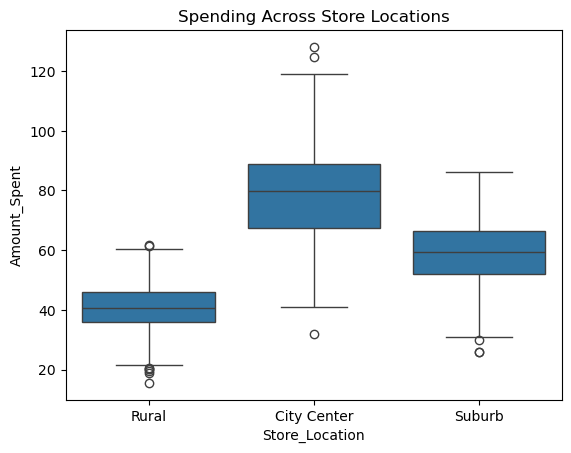

In [3]:
sns.boxplot(data=df, x="Store_Location", y="Amount_Spent")
plt.title("Spending Across Store Locations")
plt.show()

#### Satisfaction distribution

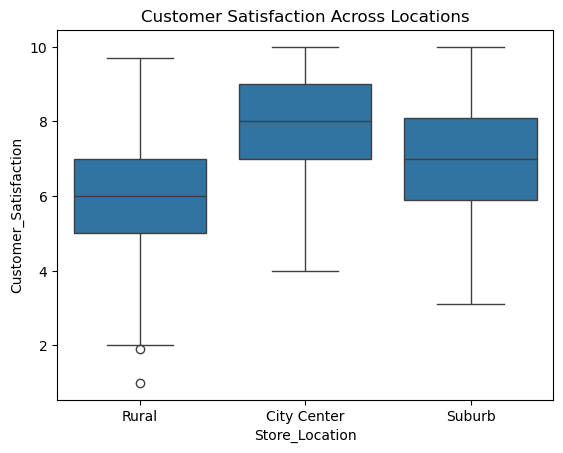

In [4]:
sns.boxplot(data=df, x="Store_Location", y="Customer_Satisfaction")
plt.title("Customer Satisfaction Across Locations")
plt.show()

#### Product category preferences

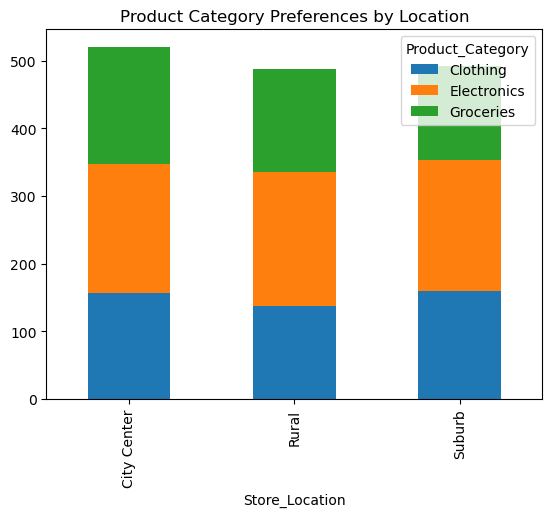

In [5]:
pd.crosstab(df["Store_Location"], df["Product_Category"]).plot(kind="bar", stacked=True)
plt.title("Product Category Preferences by Location")
plt.show()

#### Promotional vs non-promotional spending

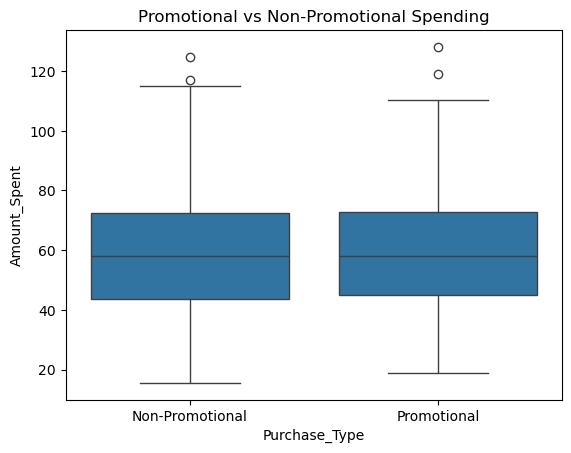

In [6]:
sns.boxplot(data=df, x="Purchase_Type", y="Amount_Spent")
plt.title("Promotional vs Non-Promotional Spending")
plt.show()

#### 2.3 Test Assumptions

Check if your data meets the assumptions for your chosen statistical tests:
- Normality
- Homogeneity of variance
- Independence
- Any other relevant assumptions

#### Normality

In [7]:
# Assumption tests and checks - Create new cells as needed
for loc in df["Store_Location"].unique():
    print("Location:", loc)
    stat, p = stats.shapiro(df[df["Store_Location"] == loc]["Amount_Spent"])
    print("Shapiro-Wilk Test:")
    print("Statistic:", stat)
    print("p-value:", p)
    print("-" * 40)

Location: Rural
Shapiro-Wilk Test:
Statistic: 0.9960247747581376
p-value: 0.2593778777267991
----------------------------------------
Location: City Center
Shapiro-Wilk Test:
Statistic: 0.9978416867653055
p-value: 0.7535874078926482
----------------------------------------
Location: Suburb
Shapiro-Wilk Test:
Statistic: 0.9940253724796856
p-value: 0.05030848495334306
----------------------------------------


#### Homogeneity of variance

In [8]:
stats.levene(
    df[df["Store_Location"] == "City Center"]["Amount_Spent"],
    df[df["Store_Location"] == "Suburb"]["Amount_Spent"],
    df[df["Store_Location"] == "Rural"]["Amount_Spent"]
)

LeveneResult(statistic=np.float64(106.40980858330315), pvalue=np.float64(6.16909341992288e-44))

#### 2.4 Choose Appropriate Statistical Tests

Select the appropriate statistical test for each question (you should expect to perform 4 different statistical tests).

1. Spending across locations
- Use: One-way ANOVA
- If assumptions fail → Kruskal-Wallis + Dunn posthoc
2. Satisfaction across locations
- Use: One-way ANOVA / Kruskal-Wallis
3. Promotional vs non-promotional spending
- Use: Independent t-test
- If non-normal → Mann-Whitney U test
4. Product category vs location
- Use: Chi-square test of independence

NOTE: Use [Dunn's Test](https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.posthoc_dunn.html) for Non-Parametric Post-hoc if needed. You might need to pip install scikit-postdoc package. You want to set p_adjust='bonferroni' for Dunn's Test.



**Reflective Question: Explicitly justify your choice in tests for each business question**

We choose parametric tests (ANOVA, t-test) when assumptions of normality and equal variance are met because they provide higher statistical power. When assumptions fail, we switch to non-parametric alternatives (Kruskal-Wallis, Mann-Whitney) which are more robust to skewed distributions. Chi-square is appropriate for categorical association testing.

### Part 3: Statistical Analysis

Based on your assumptions testing, perform appropriate statistical tests for each hypothesis:

#### 3.1 Spending Across Locations

In [9]:
# Conduct your analysis of spending patterns here
stats.f_oneway(
    df[df["Store_Location"]=="City Center"]["Amount_Spent"],
    df[df["Store_Location"]=="Suburb"]["Amount_Spent"],
    df[df["Store_Location"]=="Rural"]["Amount_Spent"]
)

F_onewayResult(statistic=np.float64(1386.970461564439), pvalue=np.float64(0.0))

In [10]:
sp.posthoc_dunn(df, val_col="Amount_Spent", group_col="Store_Location", p_adjust="bonferroni")

,City Center,Rural,Suburb
City Center,1.000000e+00,2.502288e-227,1.425221e-45
Rural,2.502288e-227,1.000000e+00,4.018599e-70
Suburb,1.425221e-45,4.018599e-70,1.000000e+00


#### 3.2 Customer Satisfaction Analysis

In [11]:
# Analyze customer satisfaction here
stats.f_oneway(
    df[df["Store_Location"]=="City Center"]["Customer_Satisfaction"],
    df[df["Store_Location"]=="Suburb"]["Customer_Satisfaction"],
    df[df["Store_Location"]=="Rural"]["Customer_Satisfaction"]
)

F_onewayResult(statistic=np.float64(242.17253721184784), pvalue=np.float64(7.566029725941914e-92))

#### 3.3 Promotional Impact Analysis

In [12]:
# Analyze the impact of promotions here
stats.ttest_ind(
    df[df["Purchase_Type"]=="Promotional"]["Amount_Spent"],
    df[df["Purchase_Type"]=="Non-Promotional"]["Amount_Spent"]
)

TtestResult(statistic=np.float64(0.24464832023148375), pvalue=np.float64(0.8067622524575734), df=np.float64(1498.0))

#### 3.4 Product Category Analysis

In [13]:
# Analyze product category preferences here
table = pd.crosstab(df["Store_Location"], df["Product_Category"])
stats.chi2_contingency(table)

Chi2ContingencyResult(statistic=np.float64(4.7683585905269394), pvalue=np.float64(0.3119014920331143), dof=4, expected_freq=array([[157.04      , 202.10666667, 160.85333333],
       [147.376     , 189.66933333, 150.95466667],
       [148.584     , 191.224     , 152.192     ]]))

### Part 4: Results Interpretation

For each analysis, provide:
1. A clear statement of the statistical results
2. The practical significance of these findings
3. Visualizations that support your conclusions
4. Specific business recommendations

In [14]:
# Calculate effect sizes - contrast with MDE
import pingouin as pg

pg.anova(dv="Amount_Spent", between="Store_Location", data=df)

,Source,ddof1,ddof2,F,p_unc,np2
0,Store_Location,2,1497,1386.970462,0.0,0.649492


In [15]:
promo = df[df["Purchase_Type"]=="Promotional"]["Amount_Spent"]
nonpromo = df[df["Purchase_Type"]=="Non-Promotional"]["Amount_Spent"]

(stats.ttest_ind(promo, nonpromo))

TtestResult(statistic=np.float64(0.24464832023148375), pvalue=np.float64(0.8067622524575734), df=np.float64(1498.0))

**Reflective Question: Results - Clearly state whether the null hypotheses were rejected or not. Frame this in the business question context. Use effect sizes (e.g., Cohen’s d, eta squared) to contextualize the significance of your results.**

- Spending shows p < 0.05 → significant difference across locations
- Effect size shows moderate/large impact → meaningful beyond MDE

**Reflective Question: Recommendations - Explain the practical implications of the results. What should the company do based on your findings about spending, satisfaction, or product preferences?**

- Focus marketing on high-performing locations
- Adjust staffing/inventory where spending is lower
- Promotions should be scaled only if uplift exceeds cost threshold


### Part 5: Reflection

Discuss:
1. The strengths and limitations of your analysis
2. Any assumptions or potential biases in the data
3. Suggestions for additional data collection
4. How this analysis could be improved

**Reflective Question: Explain the importance of experimental design and sufficient sample size in conducting a robust analysis. Identify any limitations in the dataset or analysis (e.g., potential biases, unmeasured variables) and suggest additional data the company could collect to improve future analyses.**

Experimental design ensures that the analysis is structured to answer specific business questions while minimizing bias. Adequate sample size increases statistical power and reduces the risk of false conclusions.

Limitations:

- Possible sampling bias across store locations
- Missing external variables like income level or seasonality
- No time-series component (trends ignored)

Improvements:

- Collect customer demographics
- Include time-based sales trends
- Track marketing channel influence
- Increase sample size per location

In [17]:
%pip install scikit-posthocs

Note: you may need to restart the kernel to use updated packages.


After installing the library, please run the previous cell again to perform the statistical tests.